# SA1. Regresion - articulos_ml.csv

Prediccion del numero de shares de articulos usando **Regresion Ridge** sobre una version polinomial de las variables, con la variable objetivo transformada con `log1p` por su fuerte asimetria.

## 1. Carga de datos e imputacion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib

df = pd.read_csv('articulos_ml.csv')
print(df.shape)
df.head()


(161, 8)


,Title,url,Word count,# of Links,# of comments,# Images video,Elapsed days,# Shares
0,What is Machine Learning and how do we use it ...,https://blog.signals.network/what-is-machine-l...,1888,1,2.0,2,34,200000
1,10 Companies Using Machine Learning in Cool Ways,NaN,1742,9,NaN,9,5,25000
2,How Artificial Intelligence Is Revolutionizing...,NaN,962,6,0.0,1,10,42000
3,Dbrain and the Blockchain of Artificial Intell...,NaN,1221,3,NaN,2,68,200000
4,Nasa finds entire solar system filled with eig...,NaN,2039,1,104.0,4,131,200000


In [2]:
# '# of comments' tiene nulos -> se imputan con 0 (nulo = sin registro de comentarios)
df['# of comments'] = df['# of comments'].fillna(0)
df.isnull().sum()


Title              0
url               39
Word count         0
# of Links         0
# of comments      0
# Images video     0
Elapsed days       0
# Shares           0
dtype: int64

## 2. Transformacion logaritmica de la variable objetivo

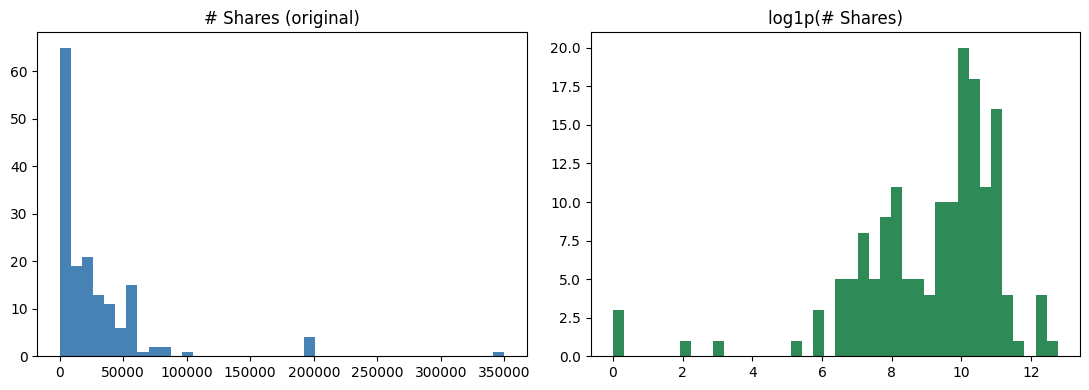

In [3]:
df['log_shares'] = np.log1p(df['# Shares'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['# Shares'], bins=40, color='steelblue')
axes[0].set_title('# Shares (original)')
axes[1].hist(df['log_shares'], bins=40, color='seagreen')
axes[1].set_title('log1p(# Shares)')
plt.tight_layout()
plt.show()


## 3. Analisis de correlacion y dispersion de los datos

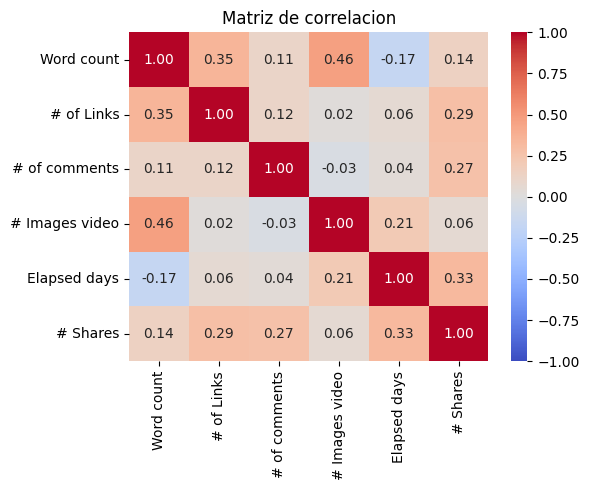

# Shares          1.000000
Elapsed days      0.325343
# of Links        0.288325
# of comments     0.269761
Word count        0.141736
# Images video    0.062170
Name: # Shares, dtype: float64


In [4]:
features = ['Word count', '# of Links', '# of comments', '# Images video', 'Elapsed days']
corr = df[features + ['# Shares']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlacion')
plt.tight_layout()
plt.savefig('imagenes_notebook_fig2_matriz_correlacion.png', dpi=110)
plt.show()
print(corr['# Shares'].sort_values(ascending=False))


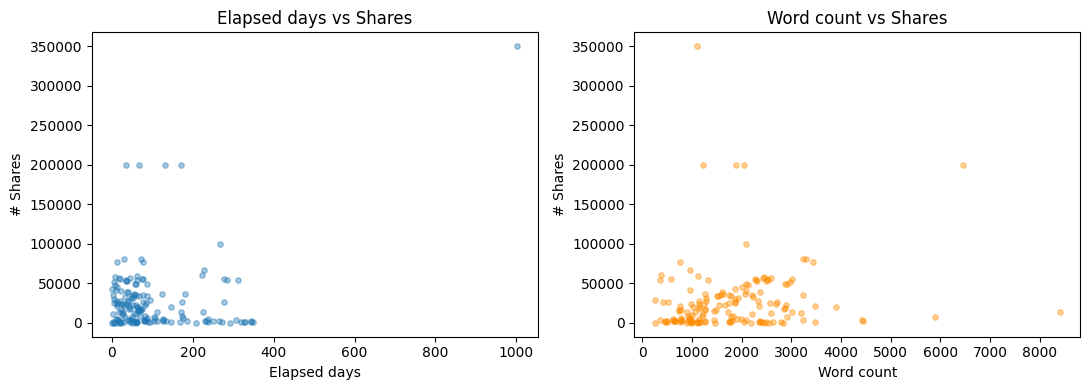

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df['Elapsed days'], df['# Shares'], alpha=0.4, s=15)
axes[0].set_xlabel('Elapsed days'); axes[0].set_ylabel('# Shares')
axes[0].set_title('Elapsed days vs Shares')
axes[1].scatter(df['Word count'], df['# Shares'], alpha=0.4, s=15, color='darkorange')
axes[1].set_xlabel('Word count'); axes[1].set_ylabel('# Shares')
axes[1].set_title('Word count vs Shares')
plt.tight_layout()
plt.savefig('imagenes_notebook_fig1_dispersion_datos.png', dpi=110)
plt.show()


## 4. Division train/test (80/20)

In [6]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['log_shares']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape


((128, 5), (33, 5))

## 5. Busqueda de hiperparametros (GridSearchCV, CV 5-fold)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {
    'poly__degree': [1, 2, 3],
    'ridge__alpha': [0.1, 1, 10, 50, 100, 200, 500, 1000]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print('Mejores hiperparametros:', grid.best_params_)
print('R2 (CV, promedio 5-fold):', round(grid.best_score_, 2))


Mejores hiperparametros: {'poly__degree': 1, 'ridge__alpha': 1000}
R2 (CV, promedio 5-fold): -0.06


## 6. Entrenamiento del modelo final y evaluacion

In [8]:
best_model = grid.best_estimator_
y_pred_log = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_test = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)
mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print('R2 test:', round(r2_test, 2))
print('MAE (escala log):', round(mae_log, 2))
print('MAE (escala real):', round(mae_real, 0))
print('RMSE (escala real):', round(rmse_real, 0))


R2 test: -0.11
MAE (escala log): 1.26
MAE (escala real): 18311.0
RMSE (escala real): 24552.0


## 7. Grafica: valores reales vs. predichos

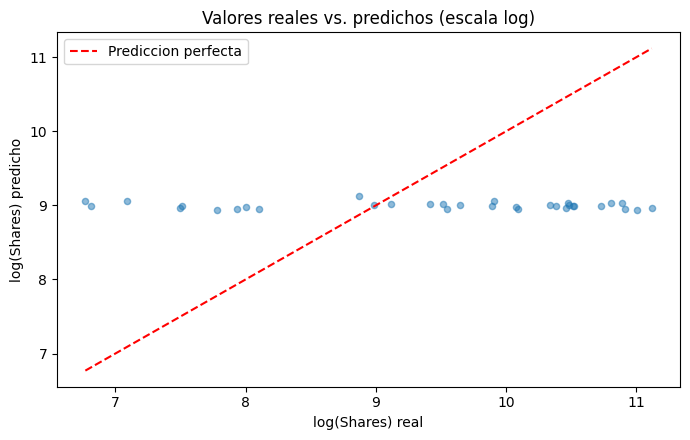

In [9]:
plt.figure(figsize=(7, 4.5))
plt.scatter(y_test, y_pred_log, alpha=0.5, s=20)
lims = [min(y_test.min(), y_pred_log.min()), max(y_test.max(), y_pred_log.max())]
plt.plot(lims, lims, 'r--', label='Prediccion perfecta')
plt.xlabel('log(Shares) real')
plt.ylabel('log(Shares) predicho')
plt.title('Valores reales vs. predichos (escala log)')
plt.legend()
plt.tight_layout()
plt.savefig('imagenes_notebook_fig3_reales_vs_predichos.png', dpi=110)
plt.show()


## 8. Guardado del modelo y de las metricas

In [10]:
import os
os.makedirs('modelo', exist_ok=True)
joblib.dump(best_model, 'modelo/modelo_regresion_articulos.pkl')

metrics = {
    "algoritmo": "Regresion Ridge (regularizacion L2) sobre target log1p(# Shares)",
    "dataset": "articulos_ml.csv",
    "mejores_hiperparametros": grid.best_params_,
    "metricas": {
        "r2_cv_5fold_promedio": round(float(grid.best_score_), 2),
        "r2_test": round(float(r2_test), 2),
        "mae_escala_log": round(float(mae_log), 2),
        "mae_escala_real_shares": round(float(mae_real), 0),
        "rmse_escala_real_shares": round(float(rmse_real), 0)
    }
}
print(json.dumps(metrics, indent=2, ensure_ascii=False))
print('\nModelo guardado en modelo/modelo_regresion_articulos.pkl')


{
  "algoritmo": "Regresion Ridge (regularizacion L2) sobre target log1p(# Shares)",
  "dataset": "articulos_ml.csv",
  "mejores_hiperparametros": {
    "poly__degree": 1,
    "ridge__alpha": 1000
  },
  "metricas": {
    "r2_cv_5fold_promedio": -0.06,
    "r2_test": -0.11,
    "mae_escala_log": 1.26,
    "mae_escala_real_shares": 18311.0,
    "rmse_escala_real_shares": 24552.0
  }
}

Modelo guardado en modelo/modelo_regresion_articulos.pkl
